In [1]:
import os
import glob
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler
from monai.losses import DiceLoss
import matplotlib.pyplot as plt
from torch.utils.data import Subset

/home/user1/charlie/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [5]:
# --- Dataset class ---
class SegFormerDataset(Dataset):
    def __init__(self, image_folder, feature_extractor):
        self.images = sorted([
            p for p in glob.glob(os.path.join(image_folder, '*.tif'))
            if 'mask' not in os.path.basename(p)
        ])
        self.masks = [
            os.path.join(image_folder,
                         os.path.basename(p).replace('.tif','_mask.tif'))
            for p in self.images
        ]
        for m in self.masks:
            if not os.path.exists(m):
                raise FileNotFoundError(f"Mask not found: {m}")

        self.fe   = feature_extractor
        self.size = tuple(self.fe.size.values())

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB").resize(self.size)
        msk = Image.open(self.masks[idx]).convert("L").resize(self.size)

        pixel_values = self.fe(images=img, return_tensors="pt")\
                           .pixel_values.squeeze(0)
        labels = torch.from_numpy(np.array(msk) > 127).long()
        return pixel_values, labels

# --- DataLoader factory ---
def get_loaders(
    folder,
    batch_size: int = 4,
    num_workers: int = 4
):
    # Define patient IDs per split
    test_ids = {44, 45, 46, 47}
    val_ids  = {36, 37, 38, 39, 40, 41, 42, 43}

    # Initialize dataset and feature extractor
    fe = SegformerFeatureExtractor.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512"
    )
    ds = SegFormerDataset(folder, fe)

    # Partition indices based on patient ID extracted from filenames
    train_idx, val_idx, test_idx = [], [], []
    for i, img_path in enumerate(ds.images):
        pid = int(os.path.basename(img_path).split('_')[0])
        if pid in test_ids:
            test_idx.append(i)
        elif pid in val_ids:
            val_idx.append(i)
        else:
            train_idx.append(i)

    # Subset the dataset
    ds_train = Subset(ds, train_idx)
    ds_val   = Subset(ds, val_idx)
    ds_test  = Subset(ds, test_idx)

    # Return wrapped DataLoaders
    return {
        'train': DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True),
        'val':   DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
        'test':  DataLoader(ds_test,  batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
    }

# --- Dice metric for binary class=1 ---
def batch_dice_coeff(logits, labels, threshold=0.5, eps=1e-6):
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = (probs > threshold).float()
    labels = labels.float()
    
    inter = (preds * labels).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + labels.sum(dim=(1, 2))
    total_pixels = preds.shape[-2] * preds.shape[-1]
    fg_ratio = (preds.sum(dim=(1, 2)) + labels.sum(dim=(1, 2))) / total_pixels

    # If both pred and gt are nearly empty (<0.1%), treat as perfect
    dice = torch.where(
        fg_ratio < 0.001,
        torch.ones_like(fg_ratio),
        (2 * inter + eps) / (union + eps)
    )
    return dice.mean().item()


# --- Training & validation with checkpointing ---
def train_segformer(loaders, epochs=20, max_lr=3e-5, experiment_name='raw'):
    # prepare model & losses
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512",
        num_labels=2, ignore_mismatched_sizes=True
    ).to(device)

    bce_loss  = torch.nn.BCEWithLogitsLoss()
    dice_loss = DiceLoss(sigmoid=True, reduction='mean')
    optimizer = Adam(model.parameters(), lr=max_lr)
    steps_per_epoch = len(loaders['train'])
    scheduler = OneCycleLR(optimizer, max_lr,
                           epochs=epochs, steps_per_epoch=steps_per_epoch)
    scaler    = GradScaler()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': []
    }

    # ← track best validation dice (highest)
    best_val_dice = 0.0
    best_path     = f"best_segformer_{experiment_name}_0504.pt"

    for epoch in range(1, epochs+1):
        # — Training (unchanged) —
        model.train()
        tloss = tdice = 0.0
        for px, lbl in tqdm(loaders['train'], desc=f"Train Ep {epoch} [{experiment_name}]"):
            px, lbl = px.to(device), lbl.to(device)
            optimizer.zero_grad()
            with autocast():
                out    = model(pixel_values=px, labels=None)
                logits = F.interpolate(out.logits,
                                       size=lbl.shape[-2:],
                                       mode="bilinear",
                                       align_corners=False)
                fg_logits = logits[:,1:2]
                fg_labels = lbl.unsqueeze(1).float()
                loss = bce_loss(fg_logits, fg_labels) + dice_loss(fg_logits, fg_labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            tloss += loss.item()
            tdice += batch_dice_coeff(logits, lbl)

        history['train_loss'].append(tloss/steps_per_epoch)
        history['train_dice'].append(tdice/steps_per_epoch)

        # — Validation (compute both loss & dice) —
        model.eval()
        vloss = vdice = 0.0
        with torch.no_grad():
            for px, lbl in loaders['val']:
                px, lbl = px.to(device), lbl.to(device)
                out    = model(pixel_values=px, labels=None)
                logits = F.interpolate(out.logits,
                                       size=lbl.shape[-2:],
                                       mode="bilinear",
                                       align_corners=False)
                fg_logits = logits[:,1:2]
                fg_labels = lbl.unsqueeze(1).float()
                loss = bce_loss(fg_logits, fg_labels) + dice_loss(fg_logits, fg_labels)
                vloss += loss.item()
                vdice += batch_dice_coeff(logits, lbl)

        avg_val_loss = vloss / len(loaders['val'])
        avg_val_dice = vdice / len(loaders['val'])
        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)

        # ← checkpoint on improved val Dice
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            torch.save(model.state_dict(), best_path)
            print(f"→ New best Dice for [{experiment_name}] at epoch {epoch}, val_dice={best_val_dice:.4f}")

        print(
            f"Epoch {epoch:02d} [{experiment_name}] → "
            f"TrL {history['train_loss'][-1]:.4f}, "
            f"TrD {history['train_dice'][-1]:.4f} | "
            f"VaL {avg_val_loss:.4f}, "
            f"VaD {avg_val_dice:.4f}"
        )

    return history


In [6]:
# --- Final test evaluation ---
def evaluate_on_test(model, test_loader):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    bce_loss  = torch.nn.BCEWithLogitsLoss()
    dice_loss = DiceLoss(sigmoid=True, reduction='mean')

    with torch.no_grad():
        for px, lbl in test_loader:
            px, lbl = px.to(device), lbl.to(device)
            out    = model(pixel_values=px, labels=None)
            logits = F.interpolate(out.logits,
                                   size=lbl.shape[-2:],
                                   mode="bilinear",
                                   align_corners=False)
            fg_logits = logits[:,1:2]
            fg_labels = lbl.unsqueeze(1).float()
            loss  = bce_loss(fg_logits, fg_labels) + dice_loss(fg_logits, fg_labels)
            total_loss += loss.item()
            total_dice += batch_dice_coeff(logits, lbl)

    n_test = len(test_loader)
    print(f"Test → Loss {total_loss/n_test:.4f}, Dice {total_dice/n_test:.4f}")


--- Experiment: raw ---


/home/user1/charlie/.conda/lib/python3.11/site-packages/transformers/models/segformer/feature_extraction_segformer.py:28: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/home/user1/charlie/.conda/lib/python3.11/site-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2

→ New best Dice for [raw] at epoch 1, val_dice=0.0599
Epoch 01 [raw] → TrL 1.6657, TrD 0.0336 | VaL 1.6088, VaD 0.0599


Train Ep 2 [raw]: 100%|██████████| 525/525 [00:43<00:00, 12.19it/s]


→ New best Dice for [raw] at epoch 2, val_dice=0.1212
Epoch 02 [raw] → TrL 1.6110, TrD 0.0548 | VaL 1.5504, VaD 0.1212


...


-- Model [raw] on test split [raw] --
Test → Loss 0.8756, Dice 0.7326

-- Model [raw] on test split [filter] --
Test → Loss 0.8722, Dice 0.6746

-- Model [raw] on test split [clahe] --


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test → Loss 0.8709, Dice 0.6886

=== Evaluating best_segformer_filter.pt on ALL test sets ===

-- Model [filter] on test split [raw] --
Test → Loss 0.9549, Dice 0.7534

-- Model [filter] on test split [filter] --
Test → Loss 0.8961, Dice 0.7297

-- Model [filter] on test split [clahe] --
Test → Loss 0.8954, Dice 0.7254

=== Evaluating best_segformer_clahe.pt on ALL test sets ===


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



-- Model [clahe] on test split [raw] --
Test → Loss 0.9242, Dice 0.7585

-- Model [clahe] on test split [filter] --
Test → Loss 0.8755, Dice 0.7287

-- Model [clahe] on test split [clahe] --
Test → Loss 0.8688, Dice 0.7304


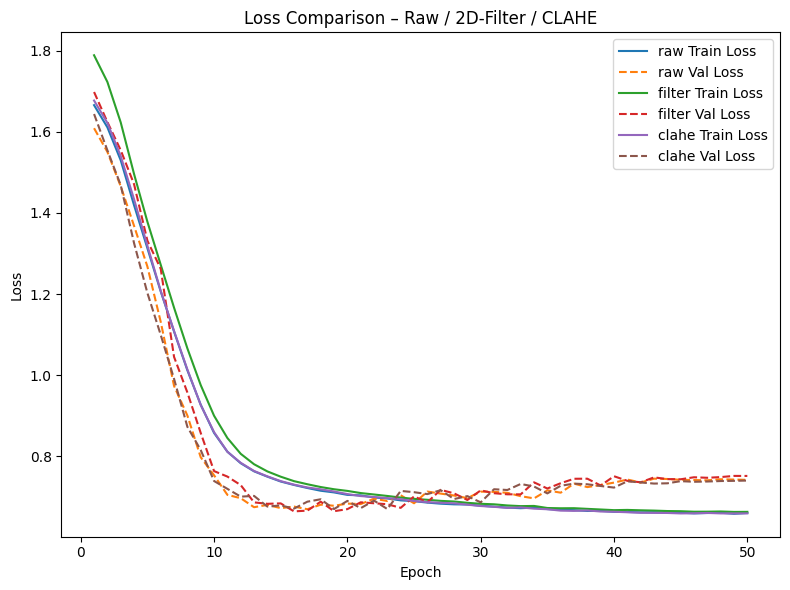

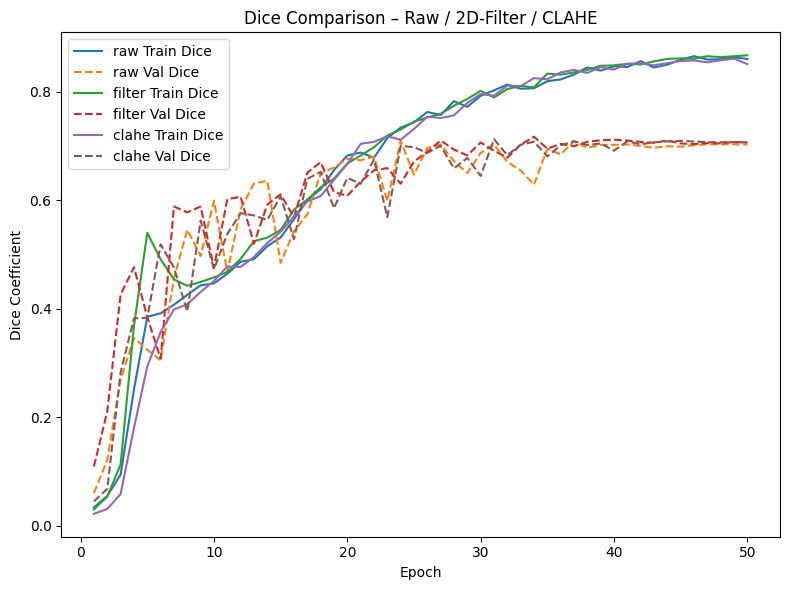

In [5]:
# --- Main experiment & plotting ---
if __name__ == "__main__":
    base_path = "/home/user1/charlie/code/deep_learning/project"
    experiments = {
        'raw':    os.path.join(base_path, "ultrasound-nerve-segmentation/train"),
        'filter': os.path.join(base_path, "ultrasound-nerve-segmentation_2Dfilter/train"),
        'clahe':  os.path.join(base_path, "ultrasound-nerve-segmentation_clahe/train"),
    }

    all_hist = {}
    loaders_dict = {}

    # Train and checkpoint each experiment
    for name, folder in experiments.items():
        print(f"\n--- Experiment: {name} ---")
        loaders = get_loaders(folder, batch_size=8)
        loaders_dict[name] = loaders
        all_hist[name] = train_segformer(
            loaders,
            epochs=50,
            max_lr=3e-5,
            experiment_name=name
        )

    # Evaluate each best model on all three test sets
    for model_name in experiments:
        print(f"\n=== Evaluating best_segformer_{model_name}.pt on ALL test sets ===")
        # re‐instantiate architecture
        model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=2, ignore_mismatched_sizes=True
        ).to(device)
        ckpt_path = f"best_segformer_{model_name}.pt"
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

        for test_name, loaders in loaders_dict.items():
            print(f"\n-- Model [{model_name}] on test split [{test_name}] --")
            evaluate_on_test(model, loaders['test'])

    # Plot Loss curves
    epochs = list(range(1, len(all_hist['raw']['train_loss'])+1))
    plt.figure(figsize=(8,6))
    for name, hist in all_hist.items():
        plt.plot(epochs, hist['train_loss'],       label=f'{name} Train Loss')
        plt.plot(epochs, hist['val_loss'], '--',   label=f'{name} Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Comparison – Raw / 2D-Filter / CLAHE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot Dice curves
    plt.figure(figsize=(8,6))
    for name, hist in all_hist.items():
        plt.plot(epochs, hist['train_dice'],       label=f'{name} Train Dice')
        plt.plot(epochs, hist['val_dice'], '--',   label=f'{name} Val Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Dice Comparison – Raw / 2D-Filter / CLAHE')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
from torchmetrics.classification import BinaryJaccardIndex
from tqdm import tqdm

# Re-create loaders_dict
from transformers import SegformerFeatureExtractor

base_path = "/home/user1/charlie/code/deep_learning/project"
experiments = {
    'raw':    os.path.join(base_path, "ultrasound-nerve-segmentation/train"),
    'filter': os.path.join(base_path, "ultrasound-nerve-segmentation_2Dfilter/train"),
    'clahe':  os.path.join(base_path, "ultrasound-nerve-segmentation_clahe/train"),
}

loaders_dict = {
    name: get_loaders(folder, batch_size=8)
    for name, folder in experiments.items()
}

def evaluate_dice_iou(model, test_loader, threshold=0.5):
    model.eval()
    total_dice = 0.0
    total_iou = 0.0
    num_batches = 0

    iou_metric = BinaryJaccardIndex(threshold=threshold).to(device)

    with torch.no_grad():
        for px, lbl in tqdm(test_loader, desc="Evaluating"):
            px, lbl = px.to(device), lbl.to(device)

            # Forward
            out = model(pixel_values=px, labels=None)
            logits = F.interpolate(out.logits, size=lbl.shape[-2:], mode="bilinear", align_corners=False)

            # Dice
            dice = batch_dice_coeff(logits, lbl)
            total_dice += dice

            # IoU
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs > threshold).int()
            total_iou += iou_metric(preds, lbl)

            num_batches += 1

    avg_dice = total_dice / num_batches
    avg_iou = total_iou / num_batches
    return avg_dice, avg_iou

# Evaluate all three models
for name in ['raw', 'filter', 'clahe']:
    print(f"\n--- Evaluation for model: {name} ---")

    # Load model
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512",
        num_labels=2,
        ignore_mismatched_sizes=True
    ).to(device)

    ckpt_path = f"best_segformer_{name}_0504.pt"
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    # Run evaluation
    for name1 in ['raw', 'filter', 'clahe']:
        dice, iou = evaluate_dice_iou(model, loaders_dict[name1]['test'])

        print(f"→ Test Dice for [{name}]: {dice:.4f}")
        print(f"→ Test IoU  for [{name}]: {iou:.4f}")


/home/user1/charlie/.conda/lib/python3.11/site-packages/transformers/models/segformer/feature_extraction_segformer.py:28: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/home/user1/charlie/.conda/lib/python3.11/site-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2


--- Evaluation for model: raw ---


Evaluating: 100%|██████████| 60/60 [00:04<00:00, 12.93it/s]
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ Test Dice for [raw]: 0.7268
→ Test IoU  for [raw]: 0.2514

--- Evaluation for model: filter ---


Evaluating: 100%|██████████| 60/60 [00:03<00:00, 15.43it/s]
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


→ Test Dice for [filter]: 0.7353
→ Test IoU  for [filter]: 0.2089

--- Evaluation for model: clahe ---


Evaluating: 100%|██████████| 60/60 [00:03<00:00, 16.35it/s]

→ Test Dice for [clahe]: 0.7200
→ Test IoU  for [clahe]: 0.2422


In [3]:
!pip install torchmetrics

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 24.9 MB/s eta 0:00:00
